# Bid landscape simulation

In [16]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def simulate_market_cpm(
    n=500_000,
    d=6,
    seed=42,

    # Market price (CPM) model: log m_cpm = mu(x) + sigma * eps
    mu0=np.log(1.5),          # baseline median ~ $1.5 CPM when features are ~0
    beta_scale=0.35,          # feature effect on log-CPM
    sigma=0.75,               # lognormal spread

    # Conversion/value model
    base_cvr=2e-4,            # typical display CVR per impression scale (0.0002)
    theta_scale=1.0,          # feature effect on CVR (via sigmoid)
    value_per_conv=50.0,      # $ per conversion (can be arbitrary)
    
    # Bidding rule in CPM dollars
    kappa=0.25,               # scales how aggressively we bid vs value
    bid_cpm_min=0.01,
    bid_cpm_max=20.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) market price in CPM dollars
    beta = rng.normal(scale=beta_scale, size=d)
    mu = mu0 + X @ beta
    eps = rng.normal(size=n)
    log_m_cpm = mu + sigma * eps
    m_cpm = np.exp(log_m_cpm)  # market clearing price in CPM dollars

    # 3) conversion probability per impression (keep it small!)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)                 # in (0,1)
    p_conv = base_cvr * p                  # in (0, base_cvr)

    # 4) value per impression in dollars, then convert to CPM dollars
    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    # 5) bid policy (CPM)
    bid_cpm = kappa * value_cpm
    bid_cpm = np.clip(bid_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (pay = market price if win; 0 otherwise)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {"mu0": mu0, "beta": beta, "sigma": sigma}
    }

# Mixture Model

In [17]:
def simulate_market_cpm_mixture(
    n=300_000,
    d=6,
    seed=42,

    # Two lognormal components in log-CPM space:
    # log M_k = mu_k(x) + sigma_k * eps
    mu0_1=np.log(1.0),         # component 1 baseline median ~$1.0
    mu0_2=np.log(3.0),         # component 2 baseline median ~$3.0
    beta_scale_1=0.25,
    beta_scale_2=0.25,
    sigma1=0.65,
    sigma2=0.85,

    # Mixing weight: pi(x)=P(component=2 | x)
    # If pi_feat_scale=0 => constant mixing prob pi0
    pi0=0.25,                  # unconditional weight on expensive regime
    pi_feat_scale=1.0,         # set 0.0 for constant mixing

    # Optional: keep same value/bid pipeline as before
    base_cvr=2e-4,
    theta_scale=1.0,
    value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05,
    bid_cpm_max=10.0,
):
    rng = np.random.default_rng(seed)

    # 1) features
    X = rng.normal(size=(n, d))

    # 2) mixture weight pi(x)
    if pi_feat_scale == 0.0:
        pi = np.full(n, pi0)
        pi_params = {"pi0": pi0, "pi_feat_scale": 0.0, "a": None}
    else:
        a = rng.normal(scale=pi_feat_scale, size=d)
        # shift so average ~ pi0
        logits = X @ a + np.log(pi0 / (1 - pi0))
        pi = sigmoid(logits)
        pi_params = {"pi0": pi0, "pi_feat_scale": pi_feat_scale, "a": a}

    # sample component: c=1 is expensive regime (component 2), c=0 is cheap regime (component 1)
    c = (rng.random(n) < pi).astype(np.int8)

    # 3) component-specific mu(x)
    beta1 = rng.normal(scale=beta_scale_1, size=d)
    beta2 = rng.normal(scale=beta_scale_2, size=d)
    mu1 = mu0_1 + X @ beta1
    mu2 = mu0_2 + X @ beta2

    # 4) sample log-CPM from selected component
    eps = rng.normal(size=n)
    log_m = np.where(c == 0, mu1 + sigma1 * eps, mu2 + sigma2 * eps)
    m_cpm = np.exp(log_m)

    # 5) value model -> bid (same as before)
    theta = rng.normal(scale=theta_scale, size=d)
    p = sigmoid(X @ theta)
    p_conv = base_cvr * p

    value_per_imp_dollars = value_per_conv * p_conv
    value_cpm = 1000.0 * value_per_imp_dollars

    bid_cpm = np.clip(kappa * value_cpm, bid_cpm_min, bid_cpm_max)

    # 6) win + pay (synthetic: pay=market price if win)
    win = (bid_cpm >= m_cpm).astype(np.int8)
    pay_cpm = m_cpm * win
    pay_dollars = pay_cpm / 1000.0

    return {
        "X": X,
        "market_price_cpm": m_cpm,
        "component": c,  # 0=cheap, 1=expensive
        "pi": pi,        # mixing prob for expensive component
        "bid_cpm": bid_cpm,
        "win": win,
        "pay_cpm": pay_cpm,
        "pay_dollars": pay_dollars,
        "p_conv": p_conv,
        "value_cpm": value_cpm,
        "params": {
            "mu0_1": mu0_1, "mu0_2": mu0_2,
            "beta1": beta1, "beta2": beta2,
            "sigma1": sigma1, "sigma2": sigma2,
            **pi_params
        }
    }

In [18]:
def bid_landscape_curves(market_price_cpm, bid_grid_cpm):
    """
    Returns:
      win_rate[b] = P(win | bid=b)
      e_cpm[b]    = E[pay_cpm per impression | bid=b]
    """
    m = market_price_cpm[:, None]     # (n,1)
    B = bid_grid_cpm[None, :]         # (1,K)
    win = (B >= m)                    # (n,K)
    win_rate = win.mean(axis=0)       # (K, )
    e_pay_cpm = (m * win).mean(axis=0)  # expected paid CPM per impression# (K, )
    return win_rate, e_pay_cpm

# Plot bid landscape curves

(80,)
(80,)


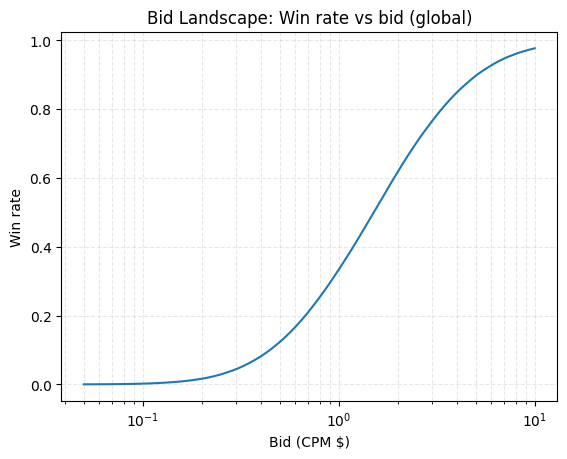

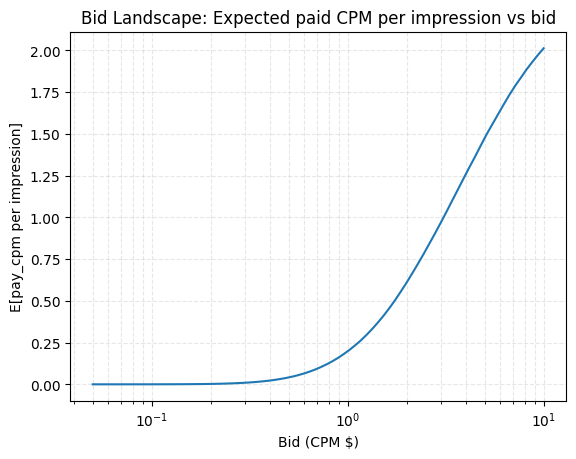

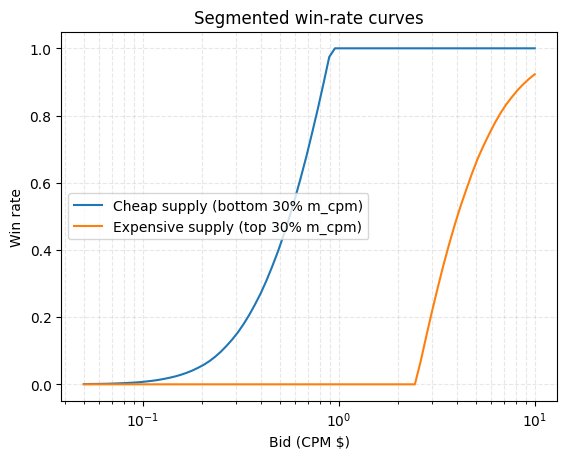

In [19]:
import matplotlib.pyplot as plt

sim = simulate_market_cpm(
    n=300_000, d=6, seed=7,
    mu0=np.log(1.5), beta_scale=0.35, sigma=0.75,
    base_cvr=2e-4, value_per_conv=50.0,
    kappa=0.25,
    bid_cpm_min=0.05, bid_cpm_max=10.0,   # force bids into your target range
)

m = sim["market_price_cpm"]
bids = np.geomspace(0.05, 10.0, 80)

win_rate, e_pay_cpm = bid_landscape_curves(m, bids)

print(win_rate.shape)
print(e_pay_cpm.shape)

# 1) Global win-rate curve
plt.figure()
plt.semilogx(bids, win_rate)
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Bid Landscape: Win rate vs bid (global)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 2) Global expected spend (CPM) per impression
plt.figure()
plt.semilogx(bids, e_pay_cpm)
plt.xlabel("Bid (CPM $)")
plt.ylabel("E[pay_cpm per impression]")
plt.title("Bid Landscape: Expected paid CPM per impression vs bid")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# 3) Segment the landscape by "supply expensiveness" (top/bottom 30% by market price)
q_lo, q_hi = np.quantile(m, [0.3, 0.7])
seg_lo = m <= q_lo
seg_hi = m >= q_hi

wr_lo, e_lo = bid_landscape_curves(m[seg_lo], bids)
wr_hi, e_hi = bid_landscape_curves(m[seg_hi], bids)

plt.figure()
plt.semilogx(bids, wr_lo, label="Cheap supply (bottom 30% m_cpm)")
plt.semilogx(bids, wr_hi, label="Expensive supply (top 30% m_cpm)")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("Segmented win-rate curves")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Simple MLE(Maximum Log-likelihood Estimation) fit
Market CPM multi-variant-log-normal model with parameters M ~ (w, b and $\sigma$)
- $
Y = \log M, \qquad 
Y \mid x \sim \mathcal{N}(\mu(x), \sigma^2), \qquad 
\mu(x) = w^\top x + b
$  

We fit w, b and $\sigma$ based on  
- All impressions contribute win/loss likelihood (Cases A/B)
- Wins with prices additionally contribute density likelihood 

In [20]:
import numpy as np
from math import sqrt, pi

# Stable normal CDF/PDF approximations (good enough for training)
def normal_pdf(z):
    return np.exp(-0.5 * z**2) / sqrt(2*pi)

def normal_cdf(z):
    # Abramowitz-Stegun approximation for erf-based CDF
    # Phi(z)=0.5*(1+erf(z/sqrt(2)))
    # We'll use a fast approximation to erf for numpy arrays.
    # erf(x) approx: sign(x)*sqrt(1-exp(-x^2*(4/pi + a*x^2)/(1+a*x^2)))
    a = 0.147
    x = z / sqrt(2)
    sign = np.sign(x)
    xx = x*x
    erf = sign * np.sqrt(1 - np.exp(-xx*(4/pi + a*xx)/(1 + a*xx)))
    return 0.5 * (1 + erf)

def fit_lognormal_censored(
    X, bid_cpm, win,
    win_price_cpm=None,      # array same length as X, NaN where missing
    lr=0.05,
    steps=2000,
    l2=1e-4,
    seed=0
):
    """
    clamp + sigma prior (shrinkage) arguments
    """
    sigma_min=0.3
    sigma_max=1.5
    sigma0=0.8
    lambda_sigma=1.0   # try 0.2 ~ 5.0
    """
    Model: log M ~ N(mu(x), sigma^2), mu(x)=b + w^T x
    Observations:
      - loss: M > bid => log-survival
      - win no price: M <= bid => log-CDF
      - win with price: log-density at observed log(price)
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    # Add intercept column
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)  # (n, d+1)
    D = d + 1

    # params
    theta = rng.normal(scale=0.01, size=D)  # intercept + weights
    log_sigma = np.log(0.8)                 # reasonable init

    eps = 1e-12

    # prepare logs
    t = np.log(np.clip(bid_cpm, 1e-6, None))

    has_price = None
    y = None
    if win_price_cpm is not None:
        has_price = np.isfinite(win_price_cpm) & (win == 1)
        y = np.log(np.clip(win_price_cpm, 1e-6, None))
    else:
        has_price = np.zeros(n, dtype=bool)

    win = win.astype(np.int8)

    for s in range(steps):
        sigma = np.exp(log_sigma)
        mu = X1 @ theta                    # (n,)
        zt = (t - mu) / sigma              # (n,)
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        # ---- Loss / Win(no price) terms ----
        # logL = win_no_price * log Phi + loss * log(1-Phi)
        win_no_price = (win == 1) & (~has_price)
        loss = (win == 0)

        # Gradients w.r.t mu and sigma for these terms:
        # For log Phi(zt): d/dmu = -(1/sigma) * (phi/Phi)
        # For log(1-Phi): d/dmu = +(1/sigma) * (phi/(1-Phi))
        ratio_win = phi / Phi
        ratio_loss = phi / (1 - Phi)

        dL_dmu = np.zeros(n)
        dL_dsigma = np.zeros(n)

        # win no price
        dL_dmu[win_no_price] += -(1/sigma) * ratio_win[win_no_price]
        dL_dsigma[win_no_price] += -(zt[win_no_price]/sigma) * ratio_win[win_no_price]

        # loss
        dL_dmu[loss] += +(1/sigma) * ratio_loss[loss]
        dL_dsigma[loss] += +(zt[loss]/sigma) * ratio_loss[loss]

        # ---- Win with observed price density terms ----
        # log f_Y(y) = -log sigma + log phi((y-mu)/sigma)
        # where zy = (y - mu)/sigma
        if has_price.any():
            idx = np.where(has_price)[0]
            zy = (y[idx] - mu[idx]) / sigma
            # d/dmu: +(zy / sigma)
            dL_dmu[idx] += zy / sigma
            # d/dsigma: (-1/sigma) + (zy^2 / sigma)
            dL_dsigma[idx] += (-1/sigma) + (zy**2 / sigma)

        # Convert to gradients for theta and log_sigma
        # mu = X1 theta  => dL/dtheta = X1^T dL/dmu
        grad_theta = X1.T @ dL_dmu / n - l2 * theta
        # sigma = exp(log_sigma): dL/dlog_sigma = dL/dsigma * sigma
        grad_log_sigma = (dL_dsigma.sum() / n) * sigma
        # sigma prior shrinkage
        grad_log_sigma += -2.0 * lambda_sigma * (log_sigma - np.log(sigma0))
        # Ascent on log-likelihood
        theta += lr * grad_theta
        log_sigma += lr * grad_log_sigma
        # hard clamp
        log_sigma = np.clip(log_sigma, np.log(sigma_min), np.log(sigma_max))

        if (s+1) % 200 == 0:
            # compute average log-likelihood (for monitoring)
            sigma = np.exp(log_sigma)
            mu = X1 @ theta
            zt = (t - mu) / sigma
            Phi = np.clip(normal_cdf(zt), eps, 1 - eps)

            ll = 0.0
            ll += np.log(Phi[win_no_price]).sum()
            ll += np.log(1 - Phi[loss]).sum()

            if has_price.any():
                zy = (y[has_price] - mu[has_price]) / sigma
                ll += (-np.log(sigma) - 0.5*zy*zy - 0.5*np.log(2*np.pi)).sum()

            ll /= n
            print(f"step {s+1:4d}  avg_ll={ll:.6f}  sigma={np.exp(log_sigma):.3f}")

    return {
        "theta": theta,          # intercept + weights
        "sigma": np.exp(log_sigma)
    }

# EM mixture model fit

In [21]:
import numpy as np
from math import sqrt, pi as PI

# ---------- Numerics helpers ----------
def logsumexp(a, axis=1):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

# ---------- Mixture fit ----------
def fit_mixture_lognormal_censored_global(
    bid_cpm,
    win,
    win_price_cpm=None,          # NaN where missing
    K=2,
    em_iters=50,
    mstep_gd_steps=30,
    lr=0.05,
    seed=0,
    sigma_min=0.2,
    sigma_max=2.0,
):
    """
    Fit global 2-component mixture:
        log M ~ sum_k pi_k N(mu_k, sigma_k^2)
    Observations:
      loss: M > bid
      win no price: M <= bid
      win with price: observe price ~= M
    """
    assert K == 2, "This implementation is written for K=2 (easy to generalize)."
    rng = np.random.default_rng(seed)
    eps = 1e-12

    bid_cpm = np.asarray(bid_cpm, dtype=float)
    win = np.asarray(win, dtype=np.int8)
    n = bid_cpm.shape[0]

    t = np.log(np.clip(bid_cpm, 1e-6, None))  # censor threshold in log space

    if win_price_cpm is None:
        has_price = np.zeros(n, dtype=bool)
        y = np.full(n, np.nan, dtype=float)
    else:
        win_price_cpm = np.asarray(win_price_cpm, dtype=float)
        has_price = np.isfinite(win_price_cpm) & (win == 1)
        y = np.log(np.clip(win_price_cpm, 1e-6, None))

    win_no_price = (win == 1) & (~has_price)
    loss = (win == 0)

    # ----- init -----
    # Use observed win prices if available, else use bid thresholds.
    if has_price.any():
        y_obs = y[has_price]
        q1, q2 = np.quantile(y_obs, [0.35, 0.75])
        mu = np.array([q1, q2])
        sigma = np.array([np.std(y_obs) + 1e-3, np.std(y_obs) + 1e-3])
    else:
        q1, q2 = np.quantile(t, [0.35, 0.75])
        mu = np.array([q1, q2])
        sigma = np.array([0.8, 0.8])

    sigma = np.clip(sigma, sigma_min, sigma_max)

    # start weights
    pi_k = np.array([0.6, 0.4])

    def component_terms(mu_k, sigma_k):
        """
        Return term_k[i] = likelihood contribution of obs i under component k:
          - loss: S = 1 - Phi(z_t)
          - win no price: F = Phi(z_t)
          - win w price: f(y)
        """
        zt = (t - mu_k) / sigma_k
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        term = np.zeros(n, dtype=float)

        # loss: S = 1 - Phi
        term[loss] = 1 - Phi[loss]

        # win w/o price: F = Phi
        term[win_no_price] = Phi[win_no_price]

        # win w price: f(y) = (1/sigma) * phi((y-mu)/sigma)
        if has_price.any():
            zy = (y[has_price] - mu_k) / sigma_k
            fy = (np.clip(normal_pdf(zy), eps, None) / sigma_k)
            term[has_price] = fy

        return np.clip(term, eps, None)

    def mstep_grad(mu_k, log_sigma_k, r_k):
        """
        Compute gradients of Q_k = sum_i r_ik * log term_k(i) w.r.t mu_k and log_sigma_k.
        """
        sigma_k = np.clip(np.exp(log_sigma_k), sigma_min, sigma_max)
        zt = (t - mu_k) / sigma_k
        Phi = np.clip(normal_cdf(zt), eps, 1 - eps)
        phi = np.clip(normal_pdf(zt), eps, None)

        dQ_dmu = 0.0
        dQ_dsigma = 0.0

        # loss: log(1-Phi)
        if loss.any():
            S = np.clip(1 - Phi[loss], eps, None)
            w = r_k[loss]
            dQ_dmu += np.sum(w * (+(1 / sigma_k) * (phi[loss] / S)))
            dQ_dsigma += np.sum(w * (+(zt[loss] / sigma_k) * (phi[loss] / S)))

        # win no price: log(Phi)
        if win_no_price.any():
            F = Phi[win_no_price]
            w = r_k[win_no_price]
            dQ_dmu += np.sum(w * (-(1 / sigma_k) * (phi[win_no_price] / F)))
            dQ_dsigma += np.sum(w * (-(zt[win_no_price] / sigma_k) * (phi[win_no_price] / F)))

        # win with price: log f(y)
        if has_price.any():
            idx = np.where(has_price)[0]
            w = r_k[idx]
            zy = (y[idx] - mu_k) / sigma_k
            # log f = -log sigma + log phi(zy)
            dQ_dmu += np.sum(w * (zy / sigma_k))
            dQ_dsigma += np.sum(w * ((-1 / sigma_k) + (zy * zy / sigma_k)))

        # convert to gradient for log_sigma: d/dlog_sigma = d/dsigma * sigma
        dQ_dlog_sigma = dQ_dsigma * sigma_k
        return dQ_dmu, dQ_dlog_sigma

    # ----- EM loop -----
    for it in range(em_iters):
        # E-step: compute responsibilities r_ik
        term0 = component_terms(mu[0], sigma[0])
        term1 = component_terms(mu[1], sigma[1])

        logp0 = np.log(pi_k[0] + eps) + np.log(term0)
        logp1 = np.log(pi_k[1] + eps) + np.log(term1)

        log_den = logsumexp(np.stack([logp0, logp1], axis=1), axis=1)
        r0 = np.exp(logp0 - log_den)
        r1 = np.exp(logp1 - log_den)

        # M-step (weights): pi_k = mean responsibilities
        pi_k = np.array([r0.mean(), r1.mean()])
        pi_k = np.clip(pi_k, 1e-6, 1 - 1e-6)
        pi_k /= pi_k.sum()

        # M-step (mu, sigma): do a few GD ascent steps (generalized EM)
        for k, rk in enumerate([r0, r1]):
            mu_k = mu[k]
            log_sigma_k = np.log(sigma[k])

            for _ in range(mstep_gd_steps):
                g_mu, g_lsig = mstep_grad(mu_k, log_sigma_k, rk)
                # normalize by n for stability
                mu_k += lr * (g_mu / n)
                log_sigma_k += lr * (g_lsig / n)
                # clamp sigma
                log_sigma_k = np.clip(log_sigma_k, np.log(sigma_min), np.log(sigma_max))

            mu[k] = mu_k
            sigma[k] = np.exp(log_sigma_k)

        # optional: print progress
        if (it + 1) % 10 == 0 or it == 0:
            # average log-likelihood
            ll = np.mean(log_den)
            print(
                f"EM {it+1:3d}  avg_ll={ll:.6f}  "
                f"pi={pi_k}  mu={mu}  sigma={sigma}"
            )

    return {"pi": pi_k, "mu": mu, "sigma": sigma}

# Generate synthetic market and bid data, and fit the model.

In [22]:
# sim = simulate_market_cpm(n=300_000, d=6, seed=7, bid_cpm_min=0.05, bid_cpm_max=10.0)
# X = sim["X"]
# bid = sim["bid_cpm"]
# win = sim["win"].astype(np.int8)
# print(X.shape, bid.shape, win.shape)

sim = simulate_market_cpm_mixture(
    n=300_000, d=6, seed=7,
    mu0_1=np.log(0.8),
    mu0_2=np.log(4.0),
    sigma1=0.6,
    sigma2=0.9,
    pi0=0.25,
    pi_feat_scale=1.0,  # set 0.0 to make mixture weight constant
    bid_cpm_min=0.05, bid_cpm_max=10.0
)
X = sim["X"]
bid = sim["bid_cpm"]
win = sim["win"].astype(np.int8)

In [23]:
# Observe price only for some wins (e.g., 30% of wins)
rng = np.random.default_rng(0)
price_obs_rate = 1.1
win_price = np.full_like(bid, np.nan, dtype=float)
mask = (win == 1) & (rng.random(len(win)) < price_obs_rate)
win_price[mask] = sim["pay_cpm"][mask]   # equals market_price_cpm in our synthetic world
print(win_price.shape)

(300000,)


In [24]:
# A few sanity checks before fitting the model.
assert len(X) == len(bid) == len(win)
assert X.ndim == 2 and bid.ndim == 1 and win.ndim == 1
assert X.shape[0] == bid.shape[0] == win.shape[0]
assert np.isfinite(bid).all() and (bid > 0).all()
assert set(np.unique(win)).issubset({0, 1})

In [25]:
# Fitting the model using fit_lognormal_censored.
fit = fit_lognormal_censored(X, bid, win, win_price_cpm=win_price, lr=0.08, steps=2000)
print("Fitted model:", fit)
#print("Fitted sigma:", fit["sigma"])

# Fitting the model using fit_mixture_lognormal_censored_global.
fit2 = fit_mixture_lognormal_censored_global(
    bid, win, win_price_cpm=win_price,
    em_iters=60,
    mstep_gd_steps=40,
    lr=0.08,
    sigma_min=0.2, sigma_max=2.0,
    seed=0
)
print("Fitted mixture model:", fit2)

step  200  avg_ll=-0.694779  sigma=0.799
step  400  avg_ll=-0.694779  sigma=0.799
step  600  avg_ll=-0.694779  sigma=0.799
step  800  avg_ll=-0.694779  sigma=0.799
step 1000  avg_ll=-0.694779  sigma=0.799
step 1200  avg_ll=-0.694779  sigma=0.799
step 1400  avg_ll=-0.694779  sigma=0.799
step 1600  avg_ll=-0.694779  sigma=0.799
step 1800  avg_ll=-0.694779  sigma=0.799
step 2000  avg_ll=-0.694779  sigma=0.799
Fitted model: {'theta': array([ 0.13253258, -0.01305018, -0.17865869,  0.04553984,  0.02306104,
        0.20271164, -0.25620253]), 'sigma': 0.7992619954649438}
EM   1  avg_ll=-0.872701  pi=[0.51471855 0.48528145]  mu=[-0.32268439  0.54201295]  sigma=[0.69916505 0.72280622]
EM  10  avg_ll=-0.745997  pi=[0.48914019 0.51085981]  mu=[-0.32306334  0.80796214]  sigma=[0.656573   0.89725763]
EM  20  avg_ll=-0.745819  pi=[0.48957497 0.51042503]  mu=[-0.32022152  0.83426333]  sigma=[0.64748232 0.93555223]
EM  30  avg_ll=-0.745784  pi=[0.49098454 0.50901546]  mu=[-0.31083327  0.83784419]  sigm

# Global win-rate curve

In [26]:
def predict_winrate(fit, X, bid_grid_cpm):
    n, d = X.shape
    X1 = np.concatenate([np.ones((n,1)), X], axis=1)
    mu = X1 @ fit["theta"]
    sigma = fit["sigma"]
    t = np.log(bid_grid_cpm[None, :])
    z = (t - mu[:, None]) / sigma
    Phi = normal_cdf(z)
    return Phi.mean(axis=0)  # average over X

# ---------- Prediction: win-rate curve ----------
def predict_winrate_mixture_global(fit, bid_grid_cpm):
    eps = 1e-12
    pi_k = fit["pi"]
    mu = fit["mu"]
    sigma = fit["sigma"]

    t = np.log(np.clip(bid_grid_cpm, 1e-6, None))
    z0 = (t - mu[0]) / sigma[0]
    z1 = (t - mu[1]) / sigma[1]
    F0 = np.clip(normal_cdf(z0), eps, 1 - eps)
    F1 = np.clip(normal_cdf(z1), eps, 1 - eps)
    return pi_k[0] * F0 + pi_k[1] * F1

bids = np.geomspace(0.05, 10.0, 80)
wr_hat = predict_winrate(fit, X[:50_000], bids)  # use a sample
wr_hat_mix = predict_winrate_mixture_global(fit2, bids)

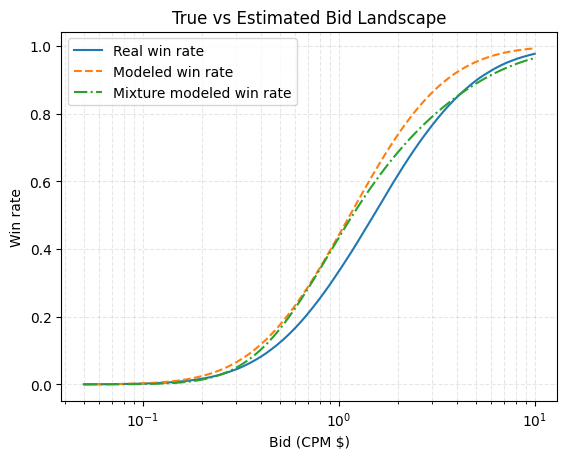

{'theta': array([ 0.13253258, -0.01305018, -0.17865869,  0.04553984,  0.02306104,
        0.20271164, -0.25620253]), 'sigma': 0.7992619954649438}
0.0001942815635293774 0.9929866331462474


In [27]:
plt.figure()
plt.semilogx(bids, win_rate, label="Real win rate")
plt.semilogx(bids, wr_hat, label="Modeled win rate", linestyle="--")
plt.semilogx(bids, wr_hat_mix, label="Mixture modeled win rate", linestyle="-.")
plt.xlabel("Bid (CPM $)")
plt.ylabel("Win rate")
plt.title("True vs Estimated Bid Landscape")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.show()

print(fit)
print(wr_hat.min(), wr_hat.max())

# print(wr_hat.shape)
# print(win_rate.shape)
# dis = np.linalg.norm(win_rate-wr_hat, ord=2)
# err_percentage = 2*dis/(np.linalg.norm(win_rate) + np.linalg.norm(wr_hat))
# print(dis)
# print(err_percentage)

# Make segment_id from X

In [ ]:
import numpy as np

def make_seg_id_from_X(X, S=50, seed=0, method="projection"):
    """
    Returns seg_id in {0,...,S-1}.
    method:
      - "projection": 1D random projection + quantile binning (fast, simple)
      - "two_projection": 2D projection -> grid bins (more expressive)
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape

    if method == "projection":
        u = rng.normal(size=d)
        u /= (np.linalg.norm(u) + 1e-12)
        score = X @ u
        # quantile edges -> equal-mass bins
        edges = np.quantile(score, np.linspace(0, 1, S + 1))
        # digitize into [0..S-1]
        seg_id = np.clip(np.digitize(score, edges[1:-1], right=False), 0, S - 1)
        return seg_id.astype(np.int32), {"u": u, "edges": edges}

    elif method == "two_projection":
        u1 = rng.normal(size=d); u1 /= (np.linalg.norm(u1) + 1e-12)
        u2 = rng.normal(size=d); u2 /= (np.linalg.norm(u2) + 1e-12)
        s1 = X @ u1
        s2 = X @ u2
        # choose grid size close to S
        g = int(np.round(np.sqrt(S)))
        g = max(2, g)
        e1 = np.quantile(s1, np.linspace(0, 1, g + 1))
        e2 = np.quantile(s2, np.linspace(0, 1, g + 1))
        b1 = np.clip(np.digitize(s1, e1[1:-1], right=False), 0, g - 1)
        b2 = np.clip(np.digitize(s2, e2[1:-1], right=False), 0, g - 1)
        seg_id = b1 * g + b2
        # if g*g > S, fold
        seg_id = seg_id % S
        return seg_id.astype(np.int32), {"u1": u1, "u2": u2, "e1": e1, "e2": e2, "g": g}

    else:
        raise ValueError("Unknown method")

In [ ]:
seg_id, seg_meta = make_seg_id_from_X(sim["X"], S=50, seed=1, method="projection")